In [14]:
import pandas as pd
from scipy.io import loadmat
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [ ]:
data = loadmat(r"C:\WINDLAB_SUMMER\file_drop\T113_4_000_1.mat")

# 1. Flip the location data so it's a table
loc_matrix = data['Location_of_measured_points']
loc_df = pd.DataFrame(loc_matrix.T, columns=['X', 'Y', 'Point_No', 'Face_No'])

# 2. Extract the pressure time-series
pressure_df = pd.DataFrame(data['Wind_pressure_coefficients'])

print(f"Total Taps: {len(loc_df)}")
print(f"Total Timesteps: {len(pressure_df)}")

print(loc_df.head())
loc


Total Taps: 300
Total Timesteps: 32768
      X     Y  Point_No  Face_No
0  0.01  0.29       1.0      1.0
1  0.03  0.29       2.0      1.0
2  0.05  0.29       3.0      1.0
3  0.07  0.29       4.0      1.0
4  0.09  0.29       5.0      1.0


In [16]:
H = data['Building_height'].item()   # Building height (m)
B = data['Building_breadth'].item()  # Building breadth (m)
D = data['Building_depth'].item()    # Building depth (m)


# 2. Create the global coordinate columns
# We initialize them with zeros first
loc_df['G_X'] = 0.0
loc_df['G_Y'] = 0.0
loc_df['G_Z'] = 0.0

# 3. Apply the transformation logic face-by-face
# Surface 1: Windward (X is horizontal, Y is height)
# Surface 1: Windward (Front)
# X starts at 0, goes to B
mask1 = loc_df['Face_No'] == 1
loc_df.loc[mask1, 'G_X'] = loc_df['X']
loc_df.loc[mask1, 'G_Y'] = 0

# Surface 2: Right Side
# X continues from B, goes to B+D
mask2 = loc_df['Face_No'] == 2
loc_df.loc[mask2, 'G_X'] = B
loc_df.loc[mask2, 'G_Y'] = loc_df['X'] - B 

# Surface 3: Leeward (Back)
# X continues from B+D, goes to B+D+B
mask3 = loc_df['Face_No'] == 3
loc_df.loc[mask3, 'G_X'] = B - (loc_df['X'] - (B + D))
loc_df.loc[mask3, 'G_Y'] = D

# Surface 4: Left Side
# X continues from B+D+B, goes to B+D+B+D
mask4 = loc_df['Face_No'] == 4
loc_df.loc[mask4, 'G_X'] = 0
loc_df.loc[mask4, 'G_Y'] = D - (loc_df['X'] - (2*B + D))

# Z is always Y in this dataset
loc_df['G_Z'] = loc_df['Y']

print(f"Mapped coordinates for {len(loc_df)} taps using B={B}, D={D}, H={H}")
loc_df.head(10)

Mapped coordinates for 300 taps using B=0.1, D=0.1, H=0.30000000000000004


,X,Y,Point_No,Face_No,G_X,G_Y,G_Z
0,0.01,0.29,1.0,1.0,0.01,0.00,0.29
1,0.03,0.29,2.0,1.0,0.03,0.00,0.29
2,0.05,0.29,3.0,1.0,0.05,0.00,0.29
3,0.07,0.29,4.0,1.0,0.07,0.00,0.29
4,0.09,0.29,5.0,1.0,0.09,0.00,0.29
5,0.11,0.29,6.0,2.0,0.10,0.01,0.29
6,0.13,0.29,7.0,2.0,0.10,0.03,0.29
7,0.15,0.29,8.0,2.0,0.10,0.05,0.29
8,0.17,0.29,9.0,2.0,0.10,0.07,0.29
9,0.19,0.29,10.0,2.0,0.10,0.09,0.29


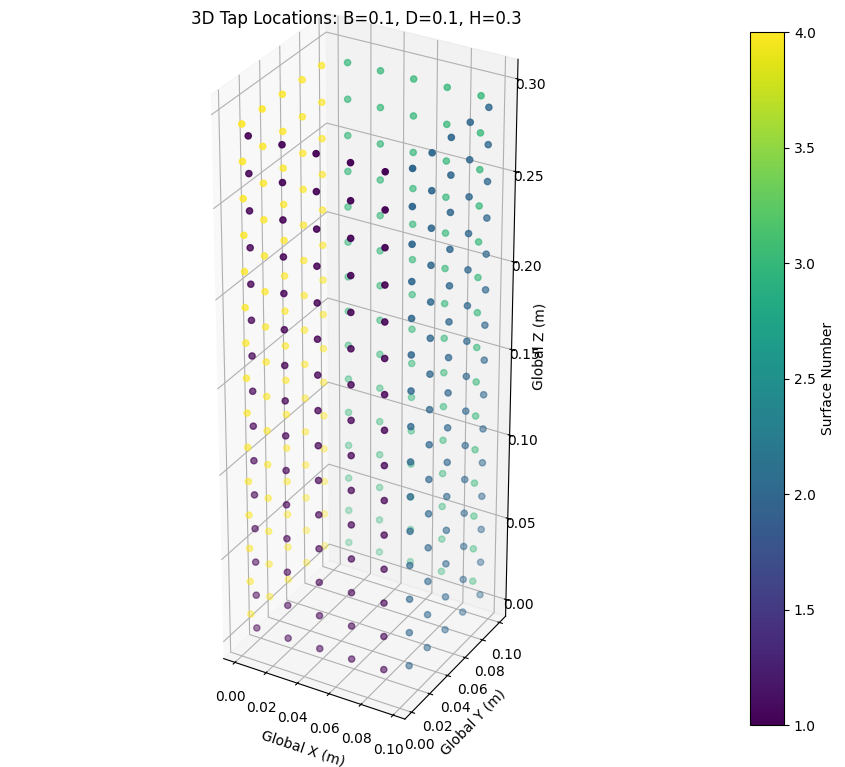

In [17]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot using our new global coordinates
# c=loc_df['Face_No'] colors the points by their surface
scatter = ax.scatter(loc_df['G_X'], loc_df['G_Y'], loc_df['G_Z'], 
                     c=loc_df['Face_No'], cmap='viridis', s=20)

# Add a colorbar to identify faces
plt.colorbar(scatter, label='Surface Number')

# Set the aspect ratio based on building dimensions from the file
ax.set_box_aspect([B, D, H]) 

ax.set_xlabel('Global X (m)')
ax.set_ylabel('Global Y (m)')
ax.set_zlabel('Global Z (m)')
plt.title(f"3D Tap Locations: B={B}, D={D}, H={round(H,2)}")

plt.show()

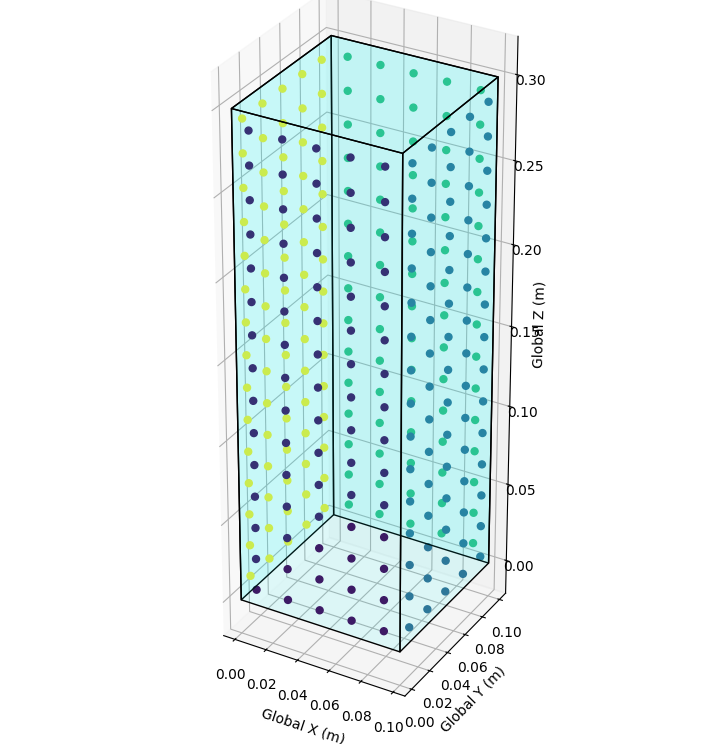

In [18]:
corners = np.array([
    [0, 0, 0], [B, 0, 0], [B, D, 0], [0, D, 0], # Bottom
    [0, 0, H], [B, 0, H], [B, D, H], [0, D, H]  # Top
])

# 2. Define the 6 faces (surfaces)
faces = [
    [corners[0], corners[1], corners[5], corners[4]], # Windward (Front)
    [corners[1], corners[2], corners[6], corners[5]], # Right Side
    [corners[2], corners[3], corners[7], corners[6]], # Leeward (Back)
    [corners[3], corners[0], corners[4], corners[7]], # Left Side
    [corners[4], corners[5], corners[6], corners[7]]  # Roof
]

# 3. Add to your existing plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Add the surfaces (semi-transparent gray)
ax.add_collection3d(Poly3DCollection(faces, facecolors='cyan', linewidths=1, edgecolors='black', alpha=.1))

# Scatter the taps on top
scatter = ax.scatter(loc_df['G_X'], loc_df['G_Y'], loc_df['G_Z'], 
                     c=loc_df['Face_No'], cmap='viridis', s=25, alpha=1)

# Match the box aspect ratio to the building dimensions
ax.set_box_aspect([B, D, H]) 

ax.set_xlabel('Global X (m)')
ax.set_ylabel('Global Y (m)')
ax.set_zlabel('Global Z (m)')
plt.show()